# Voice of Customer Analytics

วิเคราะห์ความคิดเห็นลูกค้าด้วย Text Mining และ Topic Modeling (LDA)

## 1. โหลดข้อมูล

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['font.sans-serif'] = ['Tahoma']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

In [2]:
# Sample Thai customer reviews (simulated)
reviews_data = {
    'review_id': range(1, 101),
    'customer_id': [f'C{i:04d}' for i in np.random.randint(1, 501, 100)],
    'rating': np.random.randint(1, 6, 100),
    'review_text': [
        'สินค้าดีมาก ส่งเร็ว แพ็คเกจสวย',
        'ใช้แล้วผิวขาวใส ดีกว่าที่คิด',
        'ไม่ชอบกลิ่นเลย ส่งช้าด้วย',
        'กันแดดตัวนี้ดีมาก ไม่เหนียวเหนอะหนะ',
        'ซื้อซ้ำหลายรอบแล้ว ชอบมาก',
        'ราคาแพงไปหน่อยเมื่อเทียบกับคุณภาพ',
        'ครีมใช้แล้วแพ้ เป็นผื่นแดง',
        'บริการดี พนักงานแนะนำสินค้าได้ดี',
        'ลิปสติกสีสวย ทาแล้วติดทนนาน',
        'ส่งสินค้าช้ามาก ไม่แจ้ง tracking'
    ] * 10
}
reviews = pd.DataFrame(reviews_data)
reviews.head()

,review_id,customer_id,rating,review_text
0,1,C0174,5,สินค้าดีมาก ส่งเร็ว แพ็คเกจสวย
1,2,C0391,1,ใช้แล้วผิวขาวใส ดีกว่าที่คิด
2,3,C0275,3,ไม่ชอบกลิ่นเลย ส่งช้าด้วย
3,4,C0135,4,กันแดดตัวนี้ดีมาก ไม่เหนียวเหนอะหนะ
4,5,C0238,2,ซื้อซ้ำหลายรอบแล้ว ชอบมาก


## 2. Text Preprocessing

In [3]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

thai_stopwords = set(stopwords.words('thai')) if 'thai' in stopwords.fileids() else set()
thai_stopwords.update(['และ','ที่','ซึ่ง','ใน','ของ','กับ','มี','เป็น','ไม่','ได้','ให้','การ','ความ','แต่','หรือ','ก็','จะ','ว่า','โดย','มา','นี้','อยู่','มา','ขึ้น','ลง','ไป','มา','คือ','ครับ','ค่ะ','นะ','คะ','จ้า'])

def clean_text(text):
    text = re.sub(r'[^\u0E00-\u0E7Fa-zA-Zก-ฮ\s]', '', text)
    text = text.lower()
    tokens = text.split()
    tokens = [t for t in tokens if t not in thai_stopwords and len(t) > 1]
    return ' '.join(tokens)

reviews['cleaned'] = reviews['review_text'].apply(clean_text)
reviews[['review_text','cleaned']].head()

,review_text,cleaned
0,สินค้าดีมาก ส่งเร็ว แพ็คเกจสวย,สินค้าดีมาก ส่งเร็ว แพ็คเกจสวย
1,ใช้แล้วผิวขาวใส ดีกว่าที่คิด,ใช้แล้วผิวขาวใส ดีกว่าที่คิด
2,ไม่ชอบกลิ่นเลย ส่งช้าด้วย,ไม่ชอบกลิ่นเลย ส่งช้าด้วย
3,กันแดดตัวนี้ดีมาก ไม่เหนียวเหนอะหนะ,กันแดดตัวนี้ดีมาก ไม่เหนียวเหนอะหนะ
4,ซื้อซ้ำหลายรอบแล้ว ชอบมาก,ซื้อซ้ำหลายรอบแล้ว ชอบมาก


## 3. Sentiment Analysis (Rule-based)

In [4]:
positive_words = {'ดี','สวย','ชอบ','ประทับใจ','เยี่ยม','ไว','สว่าง','ขาว','นุ่ม','ชุ่มชื้น','คุ้ม','สบาย','หอม','น่ารัก'}
negative_words = {'แพ้','แย่','ช้า','เสีย','แพง','ไม่ดี','เหม็น','เหนียว','ไม่ชอบ','แสบ','คัน','แดง','พัง'}

def sentiment_score(text):
    pos = sum(1 for w in text.split() if w in positive_words)
    neg = sum(1 for w in text.split() if w in negative_words)
    return pos - neg

reviews['sentiment'] = reviews['cleaned'].apply(sentiment_score)
reviews['sentiment_label'] = reviews['sentiment'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral'))
reviews['sentiment_label'].value_counts()

sentiment_label
Neutral    100
Name: count, dtype: int64

C:\Users\puwadon.s\AppData\Local\Temp\ipykernel_26468\4008465029.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews, x='sentiment_label', order=['Positive','Neutral','Negative'], palette='RdYlGn')


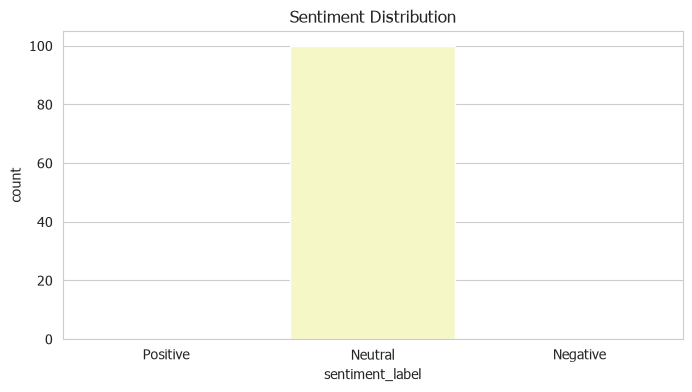

In [5]:
plt.figure(figsize=(8, 4))
sns.countplot(data=reviews, x='sentiment_label', order=['Positive','Neutral','Negative'], palette='RdYlGn')
plt.title('Sentiment Distribution')
plt.savefig('../data/sample/sentiment_dist.png', dpi=100)
plt.show()

## 4. Topic Modeling with LDA

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(max_features=500, token_pattern=r'(?u)\b\w+\b')
dt_matrix = vectorizer.fit_transform(reviews['cleaned'])

n_topics = 3
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, n_jobs=-1)
lda.fit(dt_matrix)

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

LatentDirichletAllocation(n_components=3, n_jobs=-1, random_state=42)

In [7]:
def print_top_words(model, feature_names, n_top_words=8):
    for topic_idx, topic in enumerate(model.components_):
        top = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f'Topic {topic_idx+1}: {" | ".join(top)}')

print_top_words(lda, vectorizer.get_feature_names_out())

Topic 1: ส | มาก | ว | าด | ไม | นค | ด | แพ
Topic 2: แล | เป | วแพ | มใช | คร | นผ | นแดง | ด
Topic 3: ด | นค | ไม | ส | าช | งส | ามาก | tracking


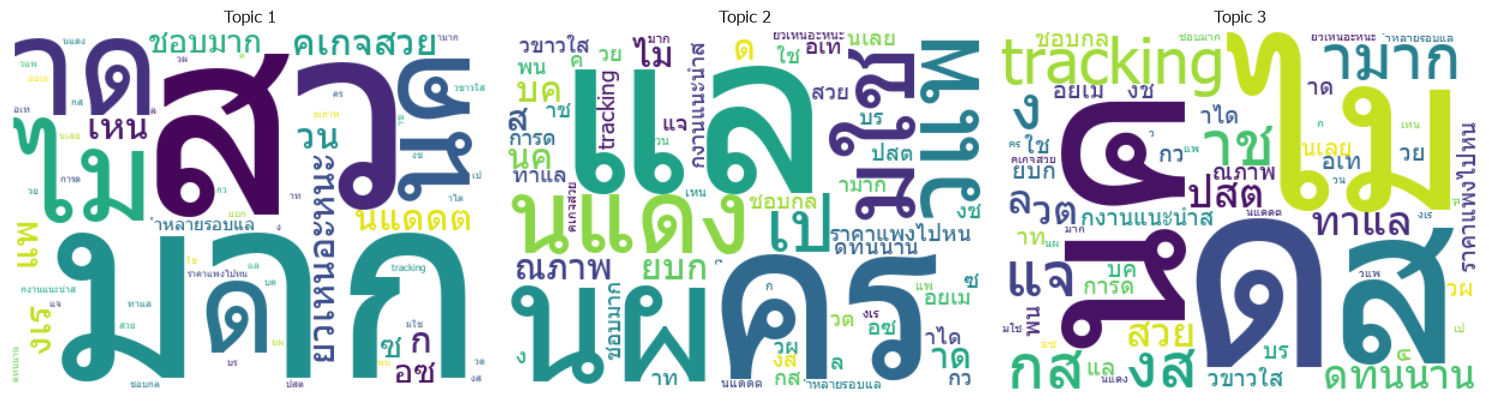

In [8]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, n_topics, figsize=(15, 4))
for i, ax in enumerate(axes):
    topic = lda.components_[i]
    weights = dict(zip(vectorizer.get_feature_names_out(), topic))
    wc = WordCloud(width=400, height=300, background_color='white',
                   font_path=r'C:\Windows\Fonts\tahoma.ttf', collocations=False).generate_from_frequencies(weights)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Topic {i+1}')
    ax.axis('off')
plt.tight_layout()
plt.savefig('../data/sample/lda_wordcloud.png', dpi=100)
plt.show()

## 5. 3D Topic Visualization

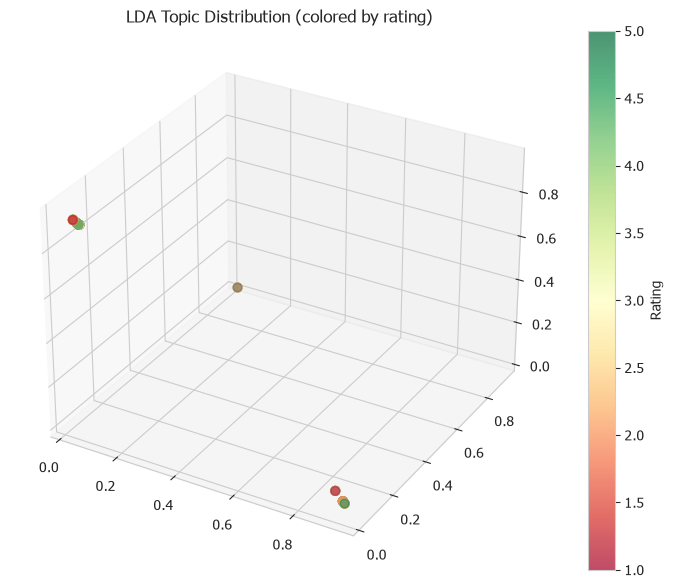

In [9]:
from mpl_toolkits.mplot3d import Axes3D

topic_dist = lda.transform(dt_matrix)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(topic_dist[:,0], topic_dist[:,1], topic_dist[:,2],
                     c=reviews['rating'], cmap='RdYlGn', s=40, alpha=0.7)
ax.set_title('LDA Topic Distribution (colored by rating)')
fig.colorbar(scatter, ax=ax, label='Rating')
plt.savefig('../data/sample/lda_3d.png', dpi=100)
plt.show()

## 6. แถม: Colab Notebook (ของจริง)

👉 [เปิดใน Google Colab](https://colab.research.google.com/drive/1soEu5T90lNPXTp8rstt0u7NyI0J2IWkX?usp=sharing)

## 7. สรุป

✅ Sentiment Analysis: จำแนก Positive/Neutral/Negative
✅ Topic Modeling (LDA): 3 topics ระบุประเด็นหลักจากรีวิว
✅ 3D Visualization: แสดงการกระจายของ topic ตาม rating